# Test RCAN HR-Aux Checkpoints

This notebook matches the data layout and model classes used by `train.py` and `train_dann.py`.


In [23]:
import json
import os
from contextlib import nullcontext
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from models import ClimateRCAN_ShallowFusion, ClimateRCAN_ShallowFusion_DANN

# Choose one of the two model names used by train.py / train_dann.py.
MODEL_NAME = "RCAN_HR_Aux_ShallowFusion"
# MODEL_NAME = "RCAN_HR_Aux_ShallowFusion_DANN"

# Set this to a trial_XXXX/best_model.pth path to bypass auto-discovery.
TRIAL_NUM = '0000'

# Set this only if the training script used --save_dir.
SAVE_DIR = None

RCM_VAR = "tas"
GCM_NAME = "CanESM2"
RCM_NAME = "RCA4"
GRID = "NAM-44i"
RCM_PRODUCT = "raw"
FACTOR = 4
EXP = 'GCM_RCM'
DATA_ROOT = "/projects/sds-lab/Shuochen/downscaling/preprocessed/"

CHECKPOINT_PATH = DATA_ROOT + f'{RCM_VAR}.{GCM_NAME}.{RCM_NAME}.day.{GRID}.{RCM_PRODUCT}.{EXP}/trained_models/{MODEL_NAME}/optuna_lr_gcm_with_hr_mask_elevation_to_hr_rcm_mse_shallowfusion/trial_{TRIAL_NUM}/best_model.pth'

INPUT_FILE = "low_res.pth"
TARGET_FILE = "high_res.pth"
HR_MASK_FILE = "high_res_mask.pth"
HR_ELEVATION_FILE = "high_res_elevation.pth"

TRAIN_START_YEAR = 1951
TRAIN_END_YEAR = 2005
VAL_START_YEAR = 2006
VAL_END_YEAR = 2099

EVAL_SPLIT = "val"  # "train", "val", "gap", or "all"
BATCH_SIZE = None   # None uses checkpoint config batch_size, then falls back to 256.
NUM_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()
SAMPLE_INDEX = 0

# HR plotting grid from preprocessing after trimming to factor-compatible shape.
# These are cell centers; plotting helpers convert them to cell edges.
PLOT_LON_CENTER_START = -124.5
PLOT_LAT_CENTER_START = 24.0
PLOT_GRID_RESOLUTION = 0.5
CONUS_VIEW_EXTENT = None  # None uses the exact HR data-cell edge extent.
MAP_FEATURE_RESOLUTION = "50m"


In [24]:
def model_is_dann(model_name):
    return model_name == "RCAN_HR_Aux_ShallowFusion_DANN"


def make_args():
    return SimpleNamespace(
        rcm_var=RCM_VAR,
        gcm_name=GCM_NAME,
        rcm_name=RCM_NAME,
        grid=GRID,
        rcm_product=RCM_PRODUCT,
        factor=FACTOR,
        data_root=DATA_ROOT,
        input_file=INPUT_FILE,
        target_file=TARGET_FILE,
        hr_mask_file=HR_MASK_FILE,
        hr_elevation_file=HR_ELEVATION_FILE,
        train_start_year=TRAIN_START_YEAR,
        train_end_year=TRAIN_END_YEAR,
        val_start_year=VAL_START_YEAR,
        val_end_year=VAL_END_YEAR,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )


def apply_config_to_args(args, config):
    for key in (
        "rcm_var",
        "gcm_name",
        "rcm_name",
        "grid",
        "rcm_product",
        "factor",
        "input_file",
        "target_file",
        "hr_mask_file",
        "hr_elevation_file",
        "train_start_year",
        "train_end_year",
        "val_start_year",
        "val_end_year",
    ):
        if key in config:
            setattr(args, key, config[key])
    return args


def experiment_folder(args):
    return os.path.join(
        args.data_root,
        (
            f"{args.rcm_var}.{args.gcm_name}.{args.rcm_name}.day."
            f"{args.grid}.{args.rcm_product}.GCM_RCM"
        ),
    )


def default_save_root(args, model_name, save_dir=None):
    if save_dir is not None:
        return save_dir
    if model_is_dann(model_name):
        run_dir = "optuna_lr_gcm_with_hr_mask_elevation_to_hr_rcm_dann"
    else:
        run_dir = "optuna_lr_gcm_with_hr_mask_elevation_to_hr_rcm_mse_shallowfusion"
    return os.path.join(experiment_folder(args), "trained_models", model_name, run_dir)


def resolve_checkpoint_path(save_root, explicit_path=None):
    if explicit_path is not None:
        ckpt_path = Path(explicit_path).expanduser()
        if not ckpt_path.exists():
            raise FileNotFoundError(f"CHECKPOINT_PATH does not exist: {ckpt_path}")
        return ckpt_path, {}

    save_root = Path(save_root)
    summary_path = save_root / "optuna_best_params.json"
    summary = {}
    if summary_path.exists():
        summary = json.loads(summary_path.read_text(encoding="utf-8"))
        best_path = summary.get("best_checkpoint_path")
        if best_path and Path(best_path).exists():
            return Path(best_path), summary
        trial_number = summary.get("best_trial_number")
        if trial_number is not None:
            fallback = save_root / f"trial_{int(trial_number):04d}" / "best_model.pth"
            if fallback.exists():
                return fallback, summary

    candidates = sorted(
        save_root.glob("trial_*/best_model.pth"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if candidates:
        print("No usable optuna_best_params.json checkpoint path; using newest trial checkpoint.")
        return candidates[0], summary

    raise FileNotFoundError(
        "Could not find a checkpoint. Set CHECKPOINT_PATH or run training until "
        f"a best_model.pth exists under {save_root}"
    )


def split_indices(args, n_samples):
    if args.train_end_year < args.train_start_year:
        raise ValueError("train_end_year must be >= train_start_year.")
    if args.val_end_year < args.val_start_year:
        raise ValueError("val_end_year must be >= val_start_year.")

    if args.gcm_name == "CanESM2":
        train_start_idx = 0
        train_end_idx = (args.train_end_year - args.train_start_year + 1) * 365
        val_start_idx = (args.val_start_year - args.train_start_year) * 365
        val_end_idx = (args.val_end_year - args.train_start_year + 1) * 365
    elif args.gcm_name == "EC-EARTH":
        def is_leap(year):
            return (year % 4 == 0 and year % 100 != 0) or (year % 400 == 0)

        def days_between_years(start_year, end_year_inclusive):
            if end_year_inclusive < start_year:
                return 0
            return sum(
                366 if is_leap(year) else 365
                for year in range(start_year, end_year_inclusive + 1)
            )

        train_start_idx = 0
        train_end_idx = days_between_years(args.train_start_year, args.train_end_year)
        val_start_idx = days_between_years(args.train_start_year, args.val_start_year - 1)
        val_end_idx = days_between_years(args.train_start_year, args.val_end_year)
    else:
        raise ValueError(f"Year split is not defined for gcm_name={args.gcm_name}")

    if train_end_idx > n_samples:
        raise ValueError(f"Training end index {train_end_idx} exceeds {n_samples} samples.")
    if val_end_idx > n_samples:
        raise ValueError(f"Validation end index {val_end_idx} exceeds {n_samples} samples.")
    return train_start_idx, train_end_idx, val_start_idx, val_end_idx


def match_sample_dim(tensor, n_samples, name):
    if tensor.shape[0] == n_samples:
        return tensor
    if tensor.shape[0] == 1:
        return tensor.expand(n_samples, -1, -1, -1).contiguous()
    raise ValueError(f"{name} has {tensor.shape[0]} samples, expected {n_samples} or 1.")


def assert_finite(tensor, name):
    if not torch.isfinite(tensor).all():
        raise ValueError(f"{name} contains NaN or Inf values.")


def safe_std(tensor):
    std = tensor.std()
    if std.item() == 0:
        raise ValueError("Cannot normalize with zero standard deviation.")
    return std


def stat_tensor(value, fallback):
    if value is None:
        value = fallback
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().float()
    return torch.tensor(float(value), dtype=torch.float32)


In [25]:
def load_dataset(args, checkpoint):
    exp_folder = experiment_folder(args)
    X = torch.load(os.path.join(exp_folder, args.input_file)).float()
    y = torch.load(os.path.join(exp_folder, args.target_file)).float()
    mask_hr = torch.load(os.path.join(exp_folder, args.hr_mask_file)).float()
    elev_hr = torch.load(os.path.join(exp_folder, args.hr_elevation_file)).float()

    if X.ndim != 4 or y.ndim != 4 or mask_hr.ndim != 4 or elev_hr.ndim != 4:
        raise ValueError("Expected X, y, mask_hr, and elev_hr to all have shape [N, C, H, W].")
    if X.shape[1] != 1 or y.shape[1] != 1 or mask_hr.shape[1] != 1 or elev_hr.shape[1] != 1:
        raise ValueError("Expected one channel each for LR input, HR target, HR mask, and HR elevation.")
    if X.shape[0] != y.shape[0]:
        raise ValueError(f"Sample mismatch: X has {X.shape[0]}, y has {y.shape[0]}.")

    mask_hr = match_sample_dim(mask_hr, y.shape[0], "mask_hr")
    elev_hr = match_sample_dim(elev_hr, y.shape[0], "elev_hr")
    if mask_hr.shape != y.shape:
        raise ValueError(f"Mask shape mismatch: {mask_hr.shape} vs {y.shape}.")
    if elev_hr.shape != y.shape:
        raise ValueError(f"Elevation shape mismatch: {elev_hr.shape} vs {y.shape}.")
    if y.shape[-2] != args.factor * X.shape[-2] or y.shape[-1] != args.factor * X.shape[-1]:
        raise ValueError("HR target dimensions do not match factor * LR input dimensions.")

    mask_hr = (mask_hr > 0.5).float().contiguous()
    elev_hr = torch.nan_to_num(elev_hr, nan=0.0, posinf=0.0, neginf=0.0).contiguous()
    hr_aux = torch.cat([mask_hr, elev_hr], dim=1).contiguous()

    assert_finite(X, "X")
    assert_finite(y, "y")
    assert_finite(mask_hr, "mask_hr")
    assert_finite(elev_hr, "elev_hr")
    assert_finite(hr_aux, "hr_aux")

    train_start_idx, train_end_idx, val_start_idx, val_end_idx = split_indices(args, X.shape[0])
    X_train = X[train_start_idx:train_end_idx]
    y_train = y[train_start_idx:train_end_idx]

    X_mean = stat_tensor(checkpoint.get("X_mean"), X_train.mean())
    X_std = stat_tensor(checkpoint.get("X_std"), safe_std(X_train))
    y_mean = stat_tensor(checkpoint.get("y_mean"), y_train.mean())
    y_std = stat_tensor(checkpoint.get("y_std"), safe_std(y_train))

    print("Experiment folder:", exp_folder)
    print("Loaded shapes:")
    print("LR GCM X :", X.shape)
    print("HR RCM y :", y.shape)
    print("HR mask  :", mask_hr.shape)
    print("HR elev  :", elev_hr.shape)
    print("HR aux   :", hr_aux.shape)
    print("Year split:")
    print(f"Train/source years: {args.train_start_year}-{args.train_end_year}")
    print(f"Val/target years  : {args.val_start_year}-{args.val_end_year}")
    print("train_start_idx:", train_start_idx)
    print("train_end_idx  :", train_end_idx)
    print("val_start_idx  :", val_start_idx)
    print("val_end_idx    :", val_end_idx)
    print("Normalization from checkpoint:")
    print("X_mean:", X_mean.item())
    print("X_std :", X_std.item())
    print("y_mean:", y_mean.item())
    print("y_std :", y_std.item())

    return {
        "exp_folder": exp_folder,
        "X": X,
        "y": y,
        "hr_aux": hr_aux,
        "mask_hr": mask_hr,
        "train_start_idx": train_start_idx,
        "train_end_idx": train_end_idx,
        "val_start_idx": val_start_idx,
        "val_end_idx": val_end_idx,
        "X_mean": X_mean,
        "X_std": X_std,
        "y_mean": y_mean,
        "y_std": y_std,
    }


def select_eval_split(data, split_name):
    split_name = split_name.lower()
    if split_name == "train":
        start, end = data["train_start_idx"], data["train_end_idx"]
    elif split_name == "val":
        start, end = data["val_start_idx"], data["val_end_idx"]
    elif split_name == "gap":
        start, end = data["train_end_idx"], data["val_start_idx"]
    elif split_name == "all":
        start, end = 0, data["X"].shape[0]
    else:
        raise ValueError('EVAL_SPLIT must be "train", "val", "gap", or "all".')

    if end <= start:
        raise ValueError(f"Selected split {split_name!r} is empty: {start}:{end}.")

    X_eval = data["X"][start:end].contiguous()
    y_eval = data["y"][start:end].contiguous()
    aux_eval = data["hr_aux"][start:end].contiguous()
    mask_eval = data["mask_hr"][start:end].contiguous()
    X_eval_n = ((X_eval - data["X_mean"]) / data["X_std"]).contiguous()
    y_eval_n = ((y_eval - data["y_mean"]) / data["y_std"]).contiguous()

    print(f"Selected EVAL_SPLIT: {split_name}")
    print("X_eval_n:", X_eval_n.shape)
    print("aux_eval:", aux_eval.shape)
    print("y_eval_n:", y_eval_n.shape)
    print("y_eval  :", y_eval.shape)
    print("mask_eval:", mask_eval.shape)

    return {
        "split_name": split_name,
        "start_idx": start,
        "end_idx": end,
        "X_eval_n": X_eval_n,
        "aux_eval": aux_eval,
        "y_eval_n": y_eval_n,
        "y_eval": y_eval,
        "mask_eval": mask_eval,
    }


In [26]:
def checkpoint_config(checkpoint, summary):
    config = dict(summary.get("config", {}))
    config.update(checkpoint.get("config", {}))
    return config


def build_model_from_checkpoint(checkpoint, model_name):
    config = checkpoint.get("config", {})
    required = ["num_resblk", "num_features", "num_groups", "reduction", "res_scale"]
    missing = [key for key in required if key not in config]
    if missing:
        raise KeyError(f"Checkpoint config is missing required model keys: {missing}")

    common_kwargs = dict(
        num_resblk=config["num_resblk"],
        num_features=config["num_features"],
        input_channels=config.get("input_channels", 1),
        output_channels=1,
        hr_aux_channels=config.get("hr_aux_channels", 2),
        scale=config.get("factor", FACTOR),
        num_groups=config["num_groups"],
        reduction=config["reduction"],
        res_scale=config["res_scale"],
    )

    if model_is_dann(model_name):
        model = ClimateRCAN_ShallowFusion_DANN(
            **common_kwargs,
            domain_hidden_dim=config.get("domain_hidden_dim", 128),
            num_domains=2,
        )
    elif model_name == "RCAN_HR_Aux_ShallowFusion":
        model = ClimateRCAN_ShallowFusion(**common_kwargs)
    else:
        raise ValueError(f"Unsupported checkpoint model_name: {model_name}")

    model.load_state_dict(checkpoint["model_state_dict"])
    return model


def forward_prediction(model, model_name, Xn, aux):
    if model_is_dann(model_name):
        y_pred_n, _ = model(
            Xn,
            aux,
            lambda_grl=0.0,
            predict=True,
            classify_domain=False,
        )
        return y_pred_n
    return model(Xn, aux)


def make_eval_loader(eval_data, batch_size):
    eval_set = TensorDataset(
        eval_data["X_eval_n"],
        eval_data["aux_eval"],
        eval_data["y_eval_n"],
        eval_data["y_eval"],
        eval_data["mask_eval"],
    )
    loader_kwargs = {"num_workers": NUM_WORKERS, "pin_memory": PIN_MEMORY}
    if NUM_WORKERS > 0:
        loader_kwargs["persistent_workers"] = True
    return DataLoader(eval_set, batch_size=batch_size, shuffle=False, **loader_kwargs)


def evaluate_model(model, model_name, eval_loader, device, y_mean, y_std):
    model.eval()
    loss_fn = nn.MSELoss()
    autocast_ctx = torch.cuda.amp.autocast if device.type == "cuda" else nullcontext
    y_mean_dev = y_mean.to(device)
    y_std_dev = y_std.to(device)

    val_loss_sum = 0.0
    val_samples = 0
    full_se_sum = 0.0
    full_pixel_count = 0
    land_se_sum = 0.0
    land_pixel_count = 0.0

    with torch.no_grad():
        for Xn, aux, yn, y_raw, mask_raw in eval_loader:
            Xn = Xn.to(device, non_blocking=True)
            aux = aux.to(device, non_blocking=True)
            yn = yn.to(device, non_blocking=True)
            y_raw = y_raw.to(device, non_blocking=True)
            mask_raw = mask_raw.to(device, non_blocking=True)

            with autocast_ctx():
                y_pred_n = forward_prediction(model, model_name, Xn, aux)
                loss = loss_fn(y_pred_n, yn)

            batch_size = Xn.shape[0]
            val_loss_sum += loss.item() * batch_size
            val_samples += batch_size

            y_pred = y_pred_n * y_std_dev + y_mean_dev
            squared_error = (y_pred - y_raw) ** 2
            full_se_sum += squared_error.sum().item()
            full_pixel_count += squared_error.numel()
            land_se_sum += (squared_error * mask_raw).sum().item()
            land_pixel_count += mask_raw.sum().item()

    return {
        "normalized_mse": val_loss_sum / val_samples,
        "physical_mse_full_image": full_se_sum / full_pixel_count,
        "physical_mse_land_only": land_se_sum / land_pixel_count,
    }


In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
args = make_args()
save_root = default_save_root(args, MODEL_NAME, SAVE_DIR)
ckpt_path, summary = resolve_checkpoint_path(save_root, CHECKPOINT_PATH)
checkpoint = torch.load(ckpt_path, map_location="cpu")
config = checkpoint_config(checkpoint, summary)

checkpoint_model_name = checkpoint.get("model_name", config.get("model_name", MODEL_NAME))
if checkpoint_model_name != MODEL_NAME:
    print(f"Notebook MODEL_NAME={MODEL_NAME}, but checkpoint model_name={checkpoint_model_name}; using checkpoint value.")
    MODEL_NAME = checkpoint_model_name

args = apply_config_to_args(args, config)
if "input_file" in checkpoint:
    args.input_file = checkpoint["input_file"]
if "target_file" in checkpoint:
    args.target_file = checkpoint["target_file"]
if "hr_mask_file" in checkpoint:
    args.hr_mask_file = checkpoint["hr_mask_file"]
if "hr_elevation_file" in checkpoint:
    args.hr_elevation_file = checkpoint["hr_elevation_file"]

batch_size = int(BATCH_SIZE or config.get("batch_size", 256))

print("Using device:", device)
print("Model name:", MODEL_NAME)
print("Checkpoint:", ckpt_path)
print("Configured batch size:", batch_size)
print("Checkpoint epoch:", checkpoint.get("epoch"))
print("Checkpoint best_val_loss:", checkpoint.get("best_val_loss"))
print("Checkpoint best_val_physical_mse_full_image:", checkpoint.get("best_val_physical_mse_full_image"))
print("Checkpoint best_val_physical_mse_land_only:", checkpoint.get("best_val_physical_mse_land_only"))

data = load_dataset(args, checkpoint)
eval_data = select_eval_split(data, EVAL_SPLIT)
eval_loader = make_eval_loader(eval_data, batch_size)

model = build_model_from_checkpoint(checkpoint, MODEL_NAME).to(device)
model.eval()
print("Model loaded.")


Using device: cuda
Model name: RCAN_HR_Aux_ShallowFusion
Checkpoint: /projects/sds-lab/Shuochen/downscaling/preprocessed/tas.CanESM2.RCA4.day.NAM-44i.raw.GCM_RCM/trained_models/RCAN_HR_Aux_ShallowFusion/optuna_lr_gcm_with_hr_mask_elevation_to_hr_rcm_mse_shallowfusion/trial_0000/best_model.pth
Configured batch size: 256
Checkpoint epoch: 41
Checkpoint best_val_loss: 0.04224768720547682
Checkpoint best_val_physical_mse_full_image: 4.329641473433344
Checkpoint best_val_physical_mse_land_only: 7.76395669976221
Experiment folder: /projects/sds-lab/Shuochen/downscaling/preprocessed/tas.CanESM2.RCA4.day.NAM-44i.raw.GCM_RCM
Loaded shapes:
LR GCM X : torch.Size([54750, 1, 13, 29])
HR RCM y : torch.Size([54750, 1, 52, 116])
HR mask  : torch.Size([54750, 1, 52, 116])
HR elev  : torch.Size([54750, 1, 52, 116])
HR aux   : torch.Size([54750, 2, 52, 116])
Year split:
Train/source years: 1951-2005
Val/target years  : 2006-2099
train_start_idx: 0
train_end_idx  : 20075
val_start_idx  : 20075
val_end_id

In [28]:
metrics = evaluate_model(
    model,
    MODEL_NAME,
    eval_loader,
    device,
    data["y_mean"],
    data["y_std"],
)

print("Evaluation results")
print("Model name                 :", MODEL_NAME)
print("Eval split                 :", eval_data["split_name"])
print("Checkpoint                 :", ckpt_path)
print("Normalized MSE             :", metrics["normalized_mse"])
print("Physical MSE full image    :", metrics["physical_mse_full_image"])
print("Physical MSE land only     :", metrics["physical_mse_land_only"])


/tmp/ipykernel_2912792/3989604588.py:90: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast_ctx():


Evaluation results
Model name                 : RCAN_HR_Aux_ShallowFusion
Eval split                 : val
Checkpoint                 : /projects/sds-lab/Shuochen/downscaling/preprocessed/tas.CanESM2.RCA4.day.NAM-44i.raw.GCM_RCM/trained_models/RCAN_HR_Aux_ShallowFusion/optuna_lr_gcm_with_hr_mask_elevation_to_hr_rcm_mse_shallowfusion/trial_0000/best_model.pth
Normalized MSE             : 0.04224768720547682
Physical MSE full image    : 4.329641473433344
Physical MSE land only     : 7.76395669976221


HR RCM target
RCAN_HR_Aux_ShallowFusion prediction
Prediction - target
Absolute error
val sample 0 (absolute index 20075) | full MSE=1.346914, land MSE=2.399895


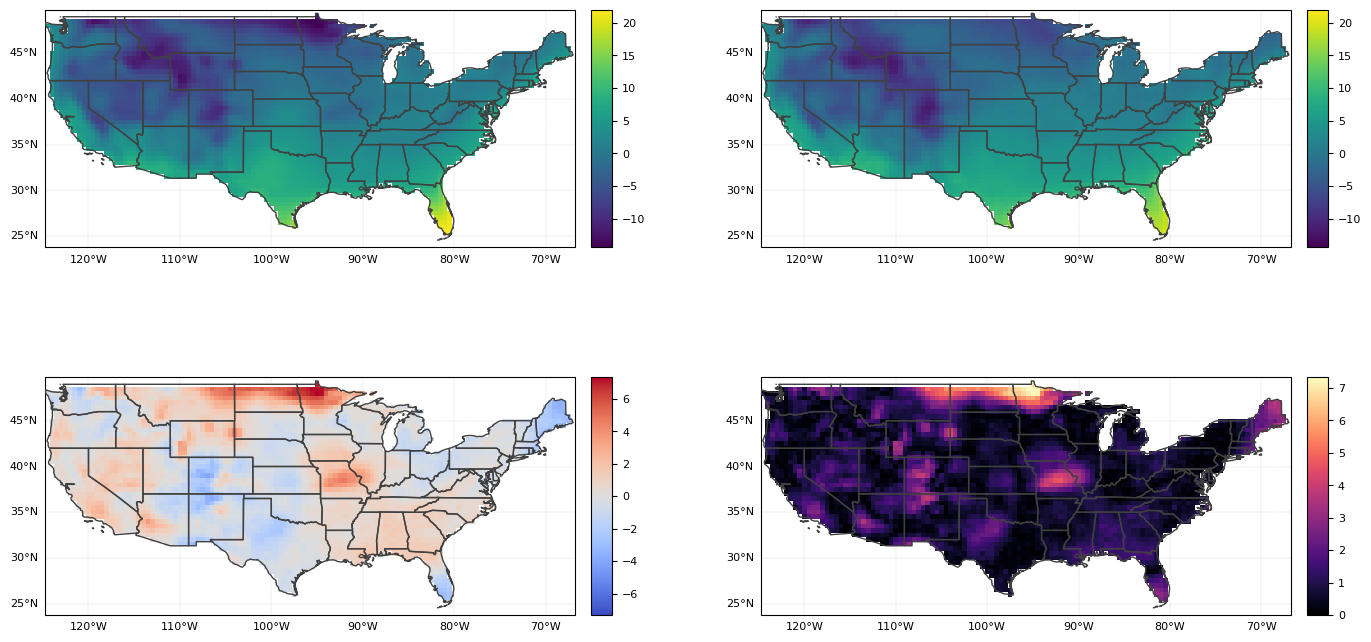

In [29]:
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    import cartopy.io.shapereader as shpreader
    from shapely.geometry import Point
    from shapely.ops import unary_union
    HAS_CARTOPY = True
except Exception as exc:
    ccrs = None
    cfeature = None
    shpreader = None
    Point = None
    unary_union = None
    HAS_CARTOPY = False
    print(f"Cartopy unavailable; falling back to plain lon/lat image axes ({exc}).")

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

_CONUS_GEOMS = None
_CONUS_UNION = None
_CONUS_MASK_CACHE = {}


def land_masked(values, mask):
    mask_bool = np.asarray(mask) > 0.5
    conus_mask = conus_mask_for_shape(mask_bool.shape)
    invalid = (~mask_bool) | (~conus_mask) | (~np.isfinite(values))
    return np.ma.masked_where(invalid, values)


def transparent_cmap(name):
    cmap = plt.get_cmap(name).copy()
    cmap.set_bad((0, 0, 0, 0))
    return cmap


def data_grid_edges(shape):
    res = globals().get("PLOT_GRID_RESOLUTION", 0.5)
    lon_start = globals().get("PLOT_LON_CENTER_START", -124.5)
    lat_start = globals().get("PLOT_LAT_CENTER_START", 24.0)
    height, width = shape
    lon_edges = lon_start - res / 2 + res * np.arange(width + 1)
    lat_edges = lat_start - res / 2 + res * np.arange(height + 1)
    return lon_edges, lat_edges


def data_grid_centers(shape):
    lon_edges, lat_edges = data_grid_edges(shape)
    lon = 0.5 * (lon_edges[:-1] + lon_edges[1:])
    lat = 0.5 * (lat_edges[:-1] + lat_edges[1:])
    return lon, lat


def data_grid_extent(shape):
    lon_edges, lat_edges = data_grid_edges(shape)
    return (lon_edges[0], lon_edges[-1], lat_edges[0], lat_edges[-1])


def get_conus_geometries(feature_resolution=None):
    global _CONUS_GEOMS
    if _CONUS_GEOMS is not None:
        return _CONUS_GEOMS
    if not HAS_CARTOPY or shpreader is None:
        _CONUS_GEOMS = []
        return _CONUS_GEOMS

    feature_resolution = feature_resolution or globals().get("MAP_FEATURE_RESOLUTION", "50m")
    states_path = shpreader.natural_earth(
        resolution=feature_resolution,
        category="cultural",
        name="admin_1_states_provinces_lakes",
    )
    geoms = []
    for record in shpreader.Reader(states_path).records():
        attrs = record.attributes
        is_us = attrs.get("admin") == "United States of America" or attrs.get("adm0_a3") == "USA"
        if not is_us:
            continue
        minx, miny, maxx, maxy = record.geometry.bounds
        if maxx <= -130 or minx >= -60 or maxy <= 22 or miny >= 52:
            continue
        geoms.append(record.geometry)
    _CONUS_GEOMS = geoms
    return _CONUS_GEOMS


def get_conus_union(feature_resolution=None):
    global _CONUS_UNION
    if _CONUS_UNION is not None:
        return _CONUS_UNION
    geoms = get_conus_geometries(feature_resolution)
    _CONUS_UNION = unary_union(geoms) if geoms and unary_union is not None else None
    return _CONUS_UNION


def conus_mask_for_shape(shape):
    key = tuple(shape)
    if key in _CONUS_MASK_CACHE:
        return _CONUS_MASK_CACHE[key]
    conus = get_conus_union()
    if conus is None or Point is None:
        mask = np.ones(shape, dtype=bool)
    else:
        lon, lat = data_grid_centers(shape)
        mask = np.zeros(shape, dtype=bool)
        for iy, y in enumerate(lat):
            for ix, x in enumerate(lon):
                mask[iy, ix] = conus.covers(Point(float(x), float(y)))
    _CONUS_MASK_CACHE[key] = mask
    return mask


def add_conus_state_boundaries(ax, feature_resolution):
    try:
        geoms = get_conus_geometries(feature_resolution)
        ax.add_feature(
            cfeature.ShapelyFeature(
                geoms,
                ccrs.PlateCarree(),
                facecolor="none",
                edgecolor="0.25",
                linewidth=1.0,
            ),
            zorder=5,
        )
    except Exception:
        ax.add_feature(
            cfeature.STATES.with_scale(feature_resolution),
            facecolor="none",
            edgecolor="0.25",
            linewidth=0.7,
            zorder=5,
        )


def add_map_background(ax, extent):
    feature_resolution = globals().get("MAP_FEATURE_RESOLUTION", "50m")
    if HAS_CARTOPY:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.set_facecolor("white")
        add_conus_state_boundaries(ax, feature_resolution)
        gl = ax.gridlines(
            draw_labels=True,
            linewidth=0.25,
            color="0.45",
            alpha=0.45,
            linestyle="--",
            zorder=1,
        )
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 8}
        gl.ylabel_style = {"size": 8}
    else:
        ax.set_facecolor("white")
        ax.set_xlim(extent[0], extent[1])
        ax.set_ylim(extent[2], extent[3])
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.grid(True, linewidth=0.25, color="0.45", alpha=0.45, linestyle="--")


def add_vertical_cbar(ax, im):
    cax = inset_axes(
        ax,
        width="4%",
        height="100%",
        loc="lower left",
        bbox_to_anchor=(1.03, 0.0, 1.0, 1.0),
        bbox_transform=ax.transAxes,
        borderpad=0,
    )
    cbar = ax.figure.colorbar(im, cax=cax, orientation="vertical")
    cbar.ax.tick_params(labelsize=8)
    return cbar


def draw_map(ax, values, mask, title, cmap, vmin=None, vmax=None):
    data_extent = data_grid_extent(mask.shape)
    view_extent = globals().get("CONUS_VIEW_EXTENT") or data_extent
    add_map_background(ax, view_extent)

    plot_values = land_masked(values, mask)
    lon_edges, lat_edges = data_grid_edges(mask.shape)
    mesh_kwargs = dict(
        cmap=transparent_cmap(cmap),
        vmin=vmin,
        vmax=vmax,
        shading="flat",
        zorder=2,
    )
    if HAS_CARTOPY:
        mesh_kwargs["transform"] = ccrs.PlateCarree()
    im = ax.pcolormesh(lon_edges, lat_edges, plot_values, **mesh_kwargs)
    print(title)
    add_vertical_cbar(ax, im)
    return im


def make_map_grid(nrows=2, ncols=2, figsize=(14, 8)):
    subplot_kw = {"projection": ccrs.PlateCarree()} if HAS_CARTOPY else {}
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, subplot_kw=subplot_kw)
    fig.subplots_adjust(left=0.05, right=0.94, bottom=0.07, top=0.9, wspace=0.35, hspace=0.24)
    return fig, np.asarray(axes).reshape(nrows, ncols)


def plot_sample(model, model_name, eval_data, data, sample_index, device):
    if sample_index < 0 or sample_index >= eval_data["X_eval_n"].shape[0]:
        raise ValueError(f"SAMPLE_INDEX must be in [0, {eval_data['X_eval_n'].shape[0] - 1}].")

    model.eval()
    y_mean_dev = data["y_mean"].to(device)
    y_std_dev = data["y_std"].to(device)

    with torch.no_grad():
        X_one = eval_data["X_eval_n"][sample_index:sample_index + 1].to(device)
        aux_one = eval_data["aux_eval"][sample_index:sample_index + 1].to(device)
        y_pred_n = forward_prediction(model, model_name, X_one, aux_one)
        y_pred = (y_pred_n * y_std_dev + y_mean_dev)[0, 0].cpu().numpy()

    y_true = eval_data["y_eval"][sample_index, 0].cpu().numpy()
    mask = eval_data["mask_eval"][sample_index, 0].cpu().numpy()
    land = (mask > 0.5) & conus_mask_for_shape(mask.shape)
    error = y_pred - y_true
    masked_error = land_masked(error, mask)

    value_pixels = np.concatenate([
        y_true[land & np.isfinite(y_true)].ravel(),
        y_pred[land & np.isfinite(y_pred)].ravel(),
    ])
    vmin = float(value_pixels.min())
    vmax = float(value_pixels.max())
    err_abs = float(np.nanmax(np.abs(masked_error)))
    if err_abs == 0:
        err_abs = 1.0

    full_mse = float(np.mean(error ** 2))
    land_mse = float(np.sum((error ** 2) * mask) / np.sum(mask))
    absolute_idx = eval_data["start_idx"] + sample_index

    fig, axes = make_map_grid()
    draw_map(axes[0, 0], y_true, mask, "HR RCM target", "viridis", vmin=vmin, vmax=vmax)
    draw_map(axes[0, 1], y_pred, mask, f"{model_name} prediction", "viridis", vmin=vmin, vmax=vmax)
    draw_map(axes[1, 0], error, mask, "Prediction - target", "coolwarm", vmin=-err_abs, vmax=err_abs)
    draw_map(axes[1, 1], np.abs(error), mask, "Absolute error", "magma", vmin=0.0, vmax=err_abs)

    plot_title = (
        f"{eval_data['split_name']} sample {sample_index} "
        f"(absolute index {absolute_idx}) | full MSE={full_mse:.6f}, land MSE={land_mse:.6f}"
    )
    print(plot_title)
    plt.show()


plot_sample(model, MODEL_NAME, eval_data, data, SAMPLE_INDEX, device)


## mean MSE for the entire validation set

Mean HR RCM target
Mean RCAN_HR_Aux_ShallowFusion prediction
Mean prediction - target
Validation set MSE
val set mean prediction (34310 samples) | full MSE=4.329348, land MSE=7.763405


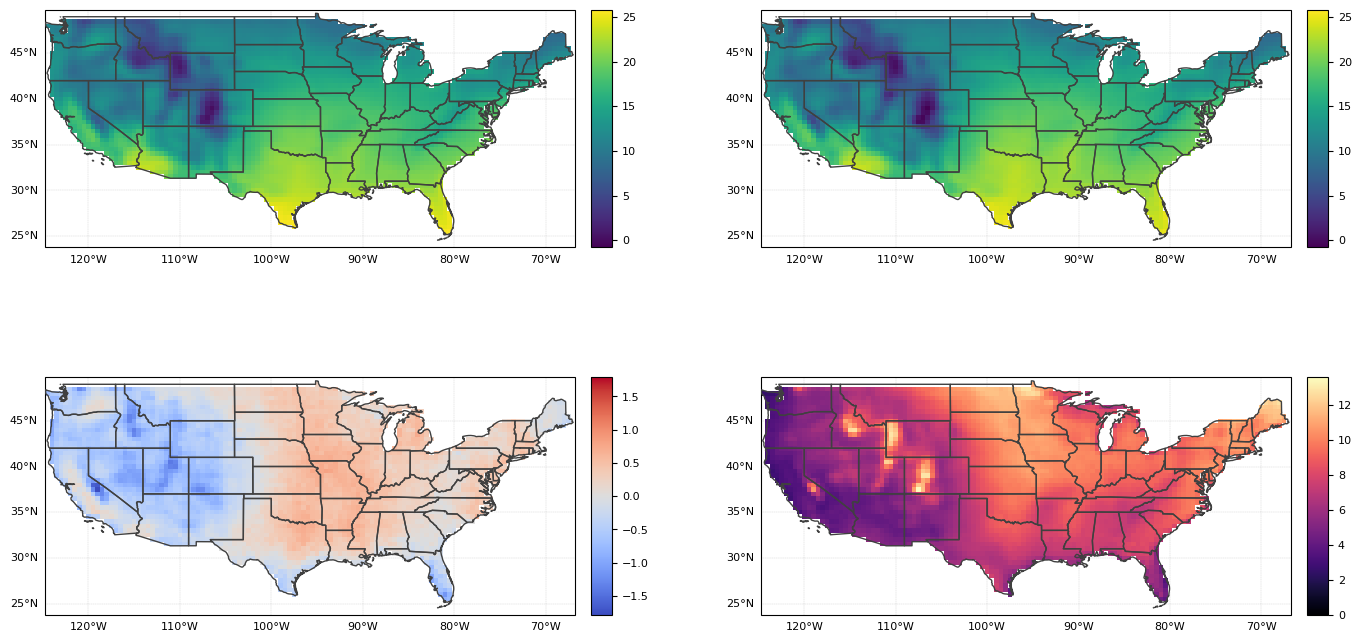

In [30]:
def plot_validation_set_mean(model, model_name, eval_loader, eval_data, data, device):
    model.eval()
    y_mean_dev = data["y_mean"].to(device)
    y_std_dev = data["y_std"].to(device)

    sum_true = None
    sum_pred = None
    sum_sq_error = None
    total_samples = 0
    full_se_sum = 0.0
    full_pixel_count = 0
    land_se_sum = 0.0
    land_pixel_count = 0.0

    with torch.no_grad():
        for Xn, aux, _, y_raw, mask_raw in eval_loader:
            Xn = Xn.to(device, non_blocking=True)
            aux = aux.to(device, non_blocking=True)
            y_raw = y_raw.to(device, non_blocking=True)
            mask_raw = mask_raw.to(device, non_blocking=True)

            y_pred_n = forward_prediction(model, model_name, Xn, aux)
            y_pred = y_pred_n * y_std_dev + y_mean_dev
            sq_error = (y_pred - y_raw) ** 2

            batch_sum_true = y_raw.cpu().sum(dim=0)
            batch_sum_pred = y_pred.cpu().sum(dim=0)
            batch_sum_sq_error = sq_error.cpu().sum(dim=0)

            if sum_true is None:
                sum_true = batch_sum_true
                sum_pred = batch_sum_pred
                sum_sq_error = batch_sum_sq_error
            else:
                sum_true += batch_sum_true
                sum_pred += batch_sum_pred
                sum_sq_error += batch_sum_sq_error

            total_samples += Xn.shape[0]
            full_se_sum += sq_error.sum().item()
            full_pixel_count += sq_error.numel()
            land_se_sum += (sq_error * mask_raw).sum().item()
            land_pixel_count += mask_raw.sum().item()

    mean_true = (sum_true / total_samples)[0].numpy()
    mean_pred = (sum_pred / total_samples)[0].numpy()
    bias = mean_pred - mean_true
    mse_map = (sum_sq_error / total_samples)[0].numpy()
    mask = eval_data["mask_eval"][0, 0].cpu().numpy()
    land = (mask > 0.5) & conus_mask_for_shape(mask.shape)

    value_pixels = np.concatenate([
        mean_true[land & np.isfinite(mean_true)].ravel(),
        mean_pred[land & np.isfinite(mean_pred)].ravel(),
    ])
    vmin = float(value_pixels.min())
    vmax = float(value_pixels.max())

    bias_abs = float(np.nanmax(np.abs(land_masked(bias, mask))))
    if bias_abs == 0:
        bias_abs = 1.0

    mse_vmax = float(np.nanmax(land_masked(mse_map, mask)))
    if mse_vmax == 0:
        mse_vmax = 1.0

    full_mse = full_se_sum / full_pixel_count
    land_mse = land_se_sum / land_pixel_count

    fig, axes = make_map_grid()
    draw_map(axes[0, 0], mean_true, mask, "Mean HR RCM target", "viridis", vmin=vmin, vmax=vmax)
    draw_map(axes[0, 1], mean_pred, mask, f"Mean {model_name} prediction", "viridis", vmin=vmin, vmax=vmax)
    draw_map(axes[1, 0], bias, mask, "Mean prediction - target", "coolwarm", vmin=-bias_abs, vmax=bias_abs)
    draw_map(axes[1, 1], mse_map, mask, "Validation set MSE", "magma", vmin=0.0, vmax=mse_vmax)

    plot_title = (
        f"{eval_data['split_name']} set mean prediction ({total_samples} samples) | "
        f"full MSE={full_mse:.6f}, land MSE={land_mse:.6f}"
    )
    print(plot_title)
    plt.show()


plot_validation_set_mean(model, MODEL_NAME, eval_loader, eval_data, data, device)


# comparison: no-DANN vs. DANN

In [31]:
REGULAR_COMPARE_TRIAL_NUM = "0001"
DANN_COMPARE_TRIAL_NUM = "0051"

REGULAR_COMPARE_MODEL_NAME = "RCAN_HR_Aux_ShallowFusion"
DANN_COMPARE_MODEL_NAME = "RCAN_HR_Aux_ShallowFusion_DANN"

Regular checkpoint: /projects/sds-lab/Shuochen/downscaling/preprocessed/tas.CanESM2.RCA4.day.NAM-44i.raw.GCM_RCM/trained_models/RCAN_HR_Aux_ShallowFusion/optuna_lr_gcm_with_hr_mask_elevation_to_hr_rcm_mse_shallowfusion/trial_0001/best_model.pth
DANN checkpoint   : /projects/sds-lab/Shuochen/downscaling/preprocessed/tas.CanESM2.RCA4.day.NAM-44i.raw.GCM_RCM/trained_models/RCAN_HR_Aux_ShallowFusion_DANN/optuna_lr_gcm_with_hr_mask_elevation_to_hr_rcm_dann/trial_0051/best_model.pth
Regular full MSE  : 4.519933488018966
DANN full MSE     : 4.288065452357416
Full MSE change   : -0.23186803566154968
Regular land MSE  : 8.071065258259948
DANN land MSE     : 7.689145504071696
Land MSE change   : -0.3819197541882513
Regular bias: prediction - target
trial 0001
DANN bias: prediction - target
trial 0051
Bias change: DANN - regular
MSE change: DANN - regular
val set comparison (34310 samples) | land MSE regular=8.071065, DANN=7.689146, change=-0.381920


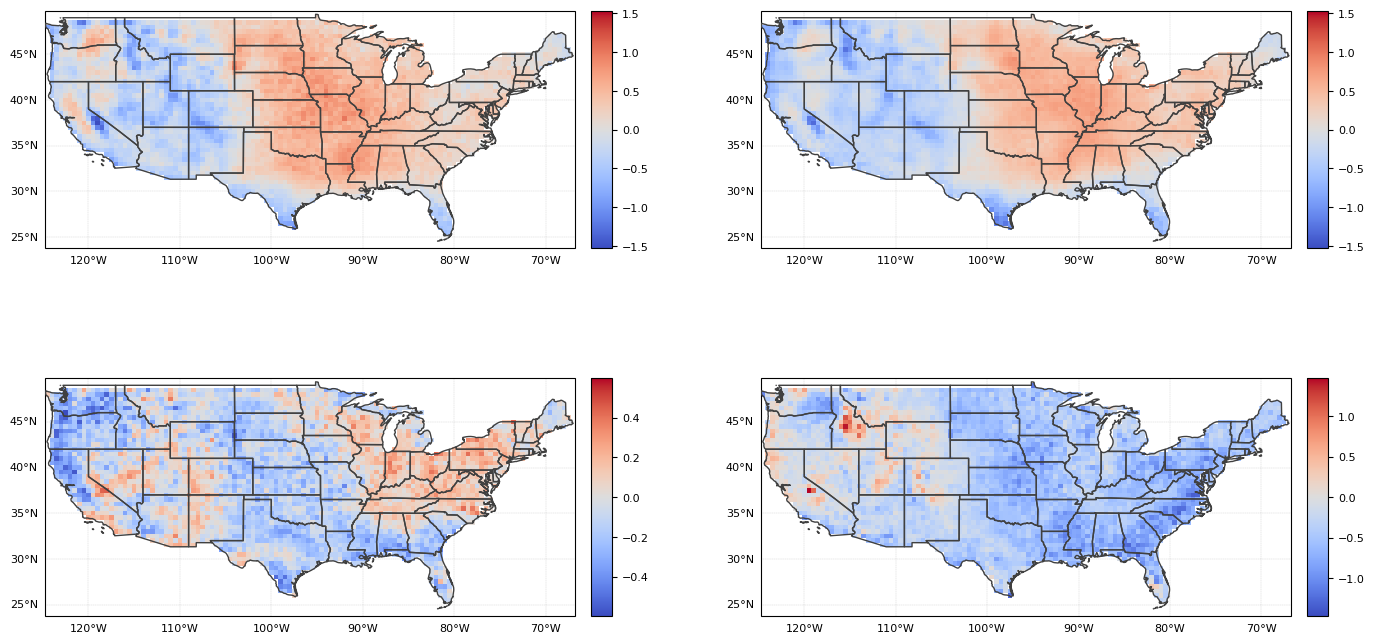

In [32]:
def compare_checkpoint_path(model_name, trial_num):
    trial_num = f"{int(trial_num):04d}"
    if model_name == "RCAN_HR_Aux_ShallowFusion_DANN":
        run_dir = "optuna_lr_gcm_with_hr_mask_elevation_to_hr_rcm_dann"
    elif model_name == "RCAN_HR_Aux_ShallowFusion":
        run_dir = "optuna_lr_gcm_with_hr_mask_elevation_to_hr_rcm_mse_shallowfusion"
    else:
        raise ValueError(f"Unsupported model_name: {model_name}")

    exp_folder = Path(DATA_ROOT) / f"{RCM_VAR}.{GCM_NAME}.{RCM_NAME}.day.{GRID}.{RCM_PRODUCT}.{EXP}"
    return exp_folder / "trained_models" / model_name / run_dir / f"trial_{trial_num}" / "best_model.pth"


def load_compare_model(model_name, trial_num, device):
    ckpt_path = compare_checkpoint_path(model_name, trial_num)
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Checkpoint does not exist: {ckpt_path}")
    ckpt = torch.load(ckpt_path, map_location="cpu")
    model = build_model_from_checkpoint(ckpt, model_name).to(device)
    model.eval()
    return model, ckpt_path, ckpt


def collect_validation_summary(model, model_name, eval_loader, eval_data, data, device):
    model.eval()
    y_mean_dev = data["y_mean"].to(device)
    y_std_dev = data["y_std"].to(device)

    sum_true = None
    sum_pred = None
    sum_sq_error = None
    total_samples = 0
    full_se_sum = 0.0
    full_pixel_count = 0
    land_se_sum = 0.0
    land_pixel_count = 0.0

    with torch.no_grad():
        for Xn, aux, _, y_raw, mask_raw in eval_loader:
            Xn = Xn.to(device, non_blocking=True)
            aux = aux.to(device, non_blocking=True)
            y_raw = y_raw.to(device, non_blocking=True)
            mask_raw = mask_raw.to(device, non_blocking=True)

            y_pred_n = forward_prediction(model, model_name, Xn, aux)
            y_pred = y_pred_n * y_std_dev + y_mean_dev
            sq_error = (y_pred - y_raw) ** 2

            batch_sum_true = y_raw.cpu().sum(dim=0)
            batch_sum_pred = y_pred.cpu().sum(dim=0)
            batch_sum_sq_error = sq_error.cpu().sum(dim=0)

            if sum_true is None:
                sum_true = batch_sum_true
                sum_pred = batch_sum_pred
                sum_sq_error = batch_sum_sq_error
            else:
                sum_true += batch_sum_true
                sum_pred += batch_sum_pred
                sum_sq_error += batch_sum_sq_error

            total_samples += Xn.shape[0]
            full_se_sum += sq_error.sum().item()
            full_pixel_count += sq_error.numel()
            land_se_sum += (sq_error * mask_raw).sum().item()
            land_pixel_count += mask_raw.sum().item()

    mean_true = (sum_true / total_samples)[0].numpy()
    mean_pred = (sum_pred / total_samples)[0].numpy()
    mse_map = (sum_sq_error / total_samples)[0].numpy()
    mask = eval_data["mask_eval"][0, 0].cpu().numpy()

    return {
        "mean_true": mean_true,
        "mean_pred": mean_pred,
        "bias": mean_pred - mean_true,
        "mse_map": mse_map,
        "full_mse": full_se_sum / full_pixel_count,
        "land_mse": land_se_sum / land_pixel_count,
        "total_samples": total_samples,
        "mask": mask,
    }


regular_model, regular_ckpt_path, regular_ckpt = load_compare_model(
    REGULAR_COMPARE_MODEL_NAME,
    REGULAR_COMPARE_TRIAL_NUM,
    device,
)
dann_model, dann_ckpt_path, dann_ckpt = load_compare_model(
    DANN_COMPARE_MODEL_NAME,
    DANN_COMPARE_TRIAL_NUM,
    device,
)

regular_summary = collect_validation_summary(
    regular_model,
    REGULAR_COMPARE_MODEL_NAME,
    eval_loader,
    eval_data,
    data,
    device,
)
dann_summary = collect_validation_summary(
    dann_model,
    DANN_COMPARE_MODEL_NAME,
    eval_loader,
    eval_data,
    data,
    device,
)

mask = regular_summary["mask"]
regular_bias = regular_summary["bias"]
dann_bias = dann_summary["bias"]
bias_change = dann_bias - regular_bias
mse_change = dann_summary["mse_map"] - regular_summary["mse_map"]

bias_abs = max(
    float(np.nanmax(np.abs(land_masked(regular_bias, mask)))),
    float(np.nanmax(np.abs(land_masked(dann_bias, mask)))),
)
if bias_abs == 0:
    bias_abs = 1.0

bias_change_abs = float(np.nanmax(np.abs(land_masked(bias_change, mask))))
if bias_change_abs == 0:
    bias_change_abs = 1.0

mse_change_abs = float(np.nanmax(np.abs(land_masked(mse_change, mask))))
if mse_change_abs == 0:
    mse_change_abs = 1.0

print("Regular checkpoint:", regular_ckpt_path)
print("DANN checkpoint   :", dann_ckpt_path)
print("Regular full MSE  :", regular_summary["full_mse"])
print("DANN full MSE     :", dann_summary["full_mse"])
print("Full MSE change   :", dann_summary["full_mse"] - regular_summary["full_mse"])
print("Regular land MSE  :", regular_summary["land_mse"])
print("DANN land MSE     :", dann_summary["land_mse"])
print("Land MSE change   :", dann_summary["land_mse"] - regular_summary["land_mse"])

fig, axes = make_map_grid()
draw_map(
    axes[0, 0],
    regular_bias,
    mask,
    f"Regular bias: prediction - target\ntrial {int(REGULAR_COMPARE_TRIAL_NUM):04d}",
    "coolwarm",
    vmin=-bias_abs,
    vmax=bias_abs,
)
draw_map(
    axes[0, 1],
    dann_bias,
    mask,
    f"DANN bias: prediction - target\ntrial {int(DANN_COMPARE_TRIAL_NUM):04d}",
    "coolwarm",
    vmin=-bias_abs,
    vmax=bias_abs,
)
draw_map(
    axes[1, 0],
    bias_change,
    mask,
    "Bias change: DANN - regular",
    "coolwarm",
    vmin=-bias_change_abs,
    vmax=bias_change_abs,
)
draw_map(
    axes[1, 1],
    mse_change,
    mask,
    "MSE change: DANN - regular",
    "coolwarm",
    vmin=-mse_change_abs,
    vmax=mse_change_abs,
)
plot_title = (
    f"{eval_data['split_name']} set comparison ({regular_summary['total_samples']} samples) | "
    f"land MSE regular={regular_summary['land_mse']:.6f}, "
    f"DANN={dann_summary['land_mse']:.6f}, "
    f"change={dann_summary['land_mse'] - regular_summary['land_mse']:.6f}"
)
print(plot_title)
plt.show()


# multiple validation sets

In [33]:
# regular model performance on multiple validation periods
REGULAR_VALSET_TRIAL_NUM = globals().get("REGULAR_COMPARE_TRIAL_NUM", "0001")
REGULAR_VALSET_MODEL_NAME = "RCAN_HR_Aux_ShallowFusion"
REGULAR_VALSET_RANGES = [
    (2006, 2099),
    (2006, 2040),
    (2041, 2070),
    (2071, 2099),
]


def regular_valset_checkpoint_path(model_name, trial_num):
    if "compare_checkpoint_path" in globals():
        return compare_checkpoint_path(model_name, trial_num)

    trial_num = f"{int(trial_num):04d}"
    run_dir = "optuna_lr_gcm_with_hr_mask_elevation_to_hr_rcm_mse_shallowfusion"
    exp_folder = Path(DATA_ROOT) / f"{RCM_VAR}.{GCM_NAME}.{RCM_NAME}.day.{GRID}.{RCM_PRODUCT}.{EXP}"
    return exp_folder / "trained_models" / model_name / run_dir / f"trial_{trial_num}" / "best_model.pth"


def load_regular_valset_model(model_name, trial_num, device):
    ckpt_path = regular_valset_checkpoint_path(model_name, trial_num)
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Checkpoint does not exist: {ckpt_path}")

    ckpt = torch.load(ckpt_path, map_location="cpu")
    ckpt_model_name = ckpt.get("model_name", ckpt.get("config", {}).get("model_name", model_name))
    if ckpt_model_name != model_name:
        raise ValueError(f"Expected {model_name}, but checkpoint model_name is {ckpt_model_name}.")

    model = build_model_from_checkpoint(ckpt, model_name).to(device)
    model.eval()
    return model, ckpt_path, ckpt


def eval_data_for_year_range(data, base_args, start_year, end_year):
    range_args = SimpleNamespace(**vars(base_args))
    range_args.val_start_year = int(start_year)
    range_args.val_end_year = int(end_year)
    _, _, start_idx, end_idx = split_indices(range_args, data["X"].shape[0])
    if end_idx <= start_idx:
        raise ValueError(f"Empty validation range: {start_year}-{end_year}")

    X_eval = data["X"][start_idx:end_idx].contiguous()
    y_eval = data["y"][start_idx:end_idx].contiguous()
    aux_eval = data["hr_aux"][start_idx:end_idx].contiguous()
    mask_eval = data["mask_hr"][start_idx:end_idx].contiguous()
    X_eval_n = ((X_eval - data["X_mean"]) / data["X_std"]).contiguous()
    y_eval_n = ((y_eval - data["y_mean"]) / data["y_std"]).contiguous()

    return {
        "split_name": f"{start_year}-{end_year}",
        "start_year": int(start_year),
        "end_year": int(end_year),
        "start_idx": start_idx,
        "end_idx": end_idx,
        "X_eval_n": X_eval_n,
        "aux_eval": aux_eval,
        "y_eval_n": y_eval_n,
        "y_eval": y_eval,
        "mask_eval": mask_eval,
    }


def ssim_batch(pred, target, data_range, window_size=11):
    pred = pred.float()
    target = target.float()
    data_range = max(float(data_range), 1e-12)
    c1 = (0.01 * data_range) ** 2
    c2 = (0.03 * data_range) ** 2
    pad = window_size // 2

    pred_pad = torch.nn.functional.pad(pred, (pad, pad, pad, pad), mode="reflect")
    target_pad = torch.nn.functional.pad(target, (pad, pad, pad, pad), mode="reflect")
    mu_pred = torch.nn.functional.avg_pool2d(pred_pad, window_size, stride=1)
    mu_target = torch.nn.functional.avg_pool2d(target_pad, window_size, stride=1)

    mu_pred_sq = mu_pred ** 2
    mu_target_sq = mu_target ** 2
    mu_pred_target = mu_pred * mu_target

    sigma_pred_sq = torch.nn.functional.avg_pool2d(pred_pad * pred_pad, window_size, stride=1) - mu_pred_sq
    sigma_target_sq = torch.nn.functional.avg_pool2d(target_pad * target_pad, window_size, stride=1) - mu_target_sq
    sigma_pred_target = torch.nn.functional.avg_pool2d(pred_pad * target_pad, window_size, stride=1) - mu_pred_target

    ssim_map = ((2 * mu_pred_target + c1) * (2 * sigma_pred_target + c2)) / (
        (mu_pred_sq + mu_target_sq + c1) * (sigma_pred_sq + sigma_target_sq + c2)
    )
    return torch.clamp(ssim_map, -1.0, 1.0).mean(dim=(1, 2, 3))


def evaluate_regular_valset_metrics(model, model_name, eval_loader, eval_data, data, device):
    model.eval()
    loss_fn = nn.MSELoss()
    y_mean_dev = data["y_mean"].to(device)
    y_std_dev = data["y_std"].to(device)
    target_range = float((eval_data["y_eval"].max() - eval_data["y_eval"].min()).item())
    if target_range <= 0:
        target_range = 1.0

    val_loss_sum = 0.0
    val_samples = 0
    full_se_sum = 0.0
    full_pixel_count = 0
    land_se_sum = 0.0
    land_pixel_count = 0.0
    ssim_sum = 0.0
    ssim_count = 0

    with torch.no_grad():
        for Xn, aux, yn, y_raw, mask_raw in eval_loader:
            Xn = Xn.to(device, non_blocking=True)
            aux = aux.to(device, non_blocking=True)
            yn = yn.to(device, non_blocking=True)
            y_raw = y_raw.to(device, non_blocking=True)
            mask_raw = mask_raw.to(device, non_blocking=True)

            y_pred_n = forward_prediction(model, model_name, Xn, aux)
            loss = loss_fn(y_pred_n, yn)
            y_pred = y_pred_n * y_std_dev + y_mean_dev
            squared_error = (y_pred - y_raw) ** 2

            batch_size = Xn.shape[0]
            val_loss_sum += loss.item() * batch_size
            val_samples += batch_size
            full_se_sum += squared_error.sum().item()
            full_pixel_count += squared_error.numel()
            land_se_sum += (squared_error * mask_raw).sum().item()
            land_pixel_count += mask_raw.sum().item()

            batch_ssim = ssim_batch(y_pred, y_raw, target_range)
            ssim_sum += batch_ssim.sum().item()
            ssim_count += batch_ssim.numel()

    full_mse = full_se_sum / full_pixel_count
    land_mse = land_se_sum / land_pixel_count
    full_rmse = float(np.sqrt(full_mse))
    land_rmse = float(np.sqrt(land_mse))
    psnr = float("inf") if full_mse == 0 else float(10.0 * np.log10((target_range ** 2) / full_mse))

    return {
        "normalized_mse": val_loss_sum / val_samples,
        "physical_mse_full_image": full_mse,
        "physical_mse_land_only": land_mse,
        "full_rmse": full_rmse,
        "land_rmse": land_rmse,
        "psnr": psnr,
        "ssim": ssim_sum / ssim_count,
    }


regular_valset_device = device if "device" in globals() else torch.device("cuda" if torch.cuda.is_available() else "cpu")
regular_valset_model, regular_valset_ckpt_path, regular_valset_ckpt = load_regular_valset_model(
    REGULAR_VALSET_MODEL_NAME,
    REGULAR_VALSET_TRIAL_NUM,
    regular_valset_device,
)
regular_valset_config = regular_valset_ckpt.get("config", {})
regular_valset_args = make_args()
regular_valset_args = apply_config_to_args(regular_valset_args, regular_valset_config)
for key in ("input_file", "target_file", "hr_mask_file", "hr_elevation_file"):
    if key in regular_valset_ckpt:
        setattr(regular_valset_args, key, regular_valset_ckpt[key])

regular_valset_data = dict(data) if "data" in globals() else load_dataset(regular_valset_args, regular_valset_ckpt)
regular_valset_data["X_mean"] = stat_tensor(regular_valset_ckpt.get("X_mean"), regular_valset_data["X_mean"])
regular_valset_data["X_std"] = stat_tensor(regular_valset_ckpt.get("X_std"), regular_valset_data["X_std"])
regular_valset_data["y_mean"] = stat_tensor(regular_valset_ckpt.get("y_mean"), regular_valset_data["y_mean"])
regular_valset_data["y_std"] = stat_tensor(regular_valset_ckpt.get("y_std"), regular_valset_data["y_std"])
regular_valset_batch_size = int(BATCH_SIZE or regular_valset_config.get("batch_size", 256))

regular_valset_results = []
for start_year, end_year in REGULAR_VALSET_RANGES:
    period_eval_data = eval_data_for_year_range(
        regular_valset_data,
        regular_valset_args,
        start_year,
        end_year,
    )
    period_eval_loader = make_eval_loader(period_eval_data, regular_valset_batch_size)
    period_metrics = evaluate_regular_valset_metrics(
        regular_valset_model,
        REGULAR_VALSET_MODEL_NAME,
        period_eval_loader,
        period_eval_data,
        regular_valset_data,
        regular_valset_device,
    )
    regular_valset_results.append(
        {
            "years": period_eval_data["split_name"],
            "samples": period_eval_data["end_idx"] - period_eval_data["start_idx"],
            "normalized_mse": period_metrics["normalized_mse"],
            "physical_mse_full_image": period_metrics["physical_mse_full_image"],
            "physical_mse_land_only": period_metrics["physical_mse_land_only"],
            "full_rmse": period_metrics["full_rmse"],
            "land_rmse": period_metrics["land_rmse"],
            "psnr": period_metrics["psnr"],
            "ssim": period_metrics["ssim"],
        }
    )

print("Regular checkpoint:", regular_valset_ckpt_path)
print(
    f"{'years':<11} {'samples':>8} {'normalized_mse':>15} "
    f"{'full_mse':>10} {'land_mse':>10} {'full_rmse':>10} "
    f"{'land_rmse':>10} {'PSNR':>10} {'SSIM':>10}"
)
for row in regular_valset_results:
    print(
        f"{row['years']:<11} "
        f"{row['samples']:>8d} "
        f"{row['normalized_mse']:>15.7f} "
        f"{row['physical_mse_full_image']:>10.3f} "
        f"{row['physical_mse_land_only']:>10.3f} "
        f"{row['full_rmse']:>10.3f} "
        f"{row['land_rmse']:>10.3f} "
        f"{row['psnr']:>10.3f} "
        f"{row['ssim']:>10.5f}"
    )


Regular checkpoint: /projects/sds-lab/Shuochen/downscaling/preprocessed/tas.CanESM2.RCA4.day.NAM-44i.raw.GCM_RCM/trained_models/RCAN_HR_Aux_ShallowFusion/optuna_lr_gcm_with_hr_mask_elevation_to_hr_rcm_mse_shallowfusion/trial_0001/best_model.pth
years        samples  normalized_mse   full_mse   land_mse  full_rmse  land_rmse       PSNR       SSIM
2006-2099      34310       0.0441049      4.520      8.071      2.126      2.841     32.413    0.89966
2006-2040      12775       0.0432327      4.431      7.911      2.105      2.813     32.107    0.88927
2041-2070      10950       0.0433675      4.444      7.937      2.108      2.817     31.830    0.89633
2071-2099      10585       0.0459206      4.706      8.403      2.169      2.899     31.265    0.90297


In [39]:
# DANN model performance for separately trained validation periods
DANN_VALSET_MODEL_NAME = 'RCAN_HR_Aux_ShallowFusion_DANN'
DANN_VALSET_BASE_DIR = Path(
    '/projects/sds-lab/Shuochen/downscaling/preprocessed/'
    'tas.CanESM2.RCA4.day.NAM-44i.raw.GCM_RCM/'
    'trained_models/RCAN_HR_Aux_ShallowFusion_DANN'
)

# Change these trial numbers to choose each period's best trial.
DANN_BEST_TRIAL_NUM_BY_PERIOD = {
    (2006, 2040): '0012',
    (2041, 2070): '0092',
    (2071, 2099): '0186',
}

DANN_RUN_DIR_BY_PERIOD = {
    (2006, 2040): 'dann_2006_2040_bs512',
    (2041, 2070): 'dann_2041_2070_bs512',
    (2071, 2099): 'dann_2071_2099_bs512',
}

# Set to one tuple, for example (2006, 2040), to show only that period.
# Leave as None to show the three matching DANN validation periods.
DANN_PERIOD_TO_SHOW = None


def selected_dann_periods():
    periods = list(DANN_RUN_DIR_BY_PERIOD)
    if DANN_PERIOD_TO_SHOW is None:
        return periods

    requested = tuple(DANN_PERIOD_TO_SHOW)
    if requested not in DANN_RUN_DIR_BY_PERIOD:
        raise ValueError(f'DANN_PERIOD_TO_SHOW must be one of {periods}, got {requested}.')
    return [requested]


def dann_valset_checkpoint_path(period):
    run_dir = DANN_RUN_DIR_BY_PERIOD[period]
    trial_num = f'{int(DANN_BEST_TRIAL_NUM_BY_PERIOD[period]):04d}'
    return DANN_VALSET_BASE_DIR / run_dir / f'trial_{trial_num}' / 'best_model.pth'


def load_dann_valset_model(period, device):
    ckpt_path = dann_valset_checkpoint_path(period)
    if not ckpt_path.exists():
        raise FileNotFoundError(f'Checkpoint does not exist: {ckpt_path}')

    ckpt = torch.load(ckpt_path, map_location='cpu')
    ckpt_model_name = ckpt.get('model_name', ckpt.get('config', {}).get('model_name', DANN_VALSET_MODEL_NAME))
    if ckpt_model_name != DANN_VALSET_MODEL_NAME:
        raise ValueError(f'Expected {DANN_VALSET_MODEL_NAME}, but checkpoint model_name is {ckpt_model_name}.')

    model = build_model_from_checkpoint(ckpt, DANN_VALSET_MODEL_NAME).to(device)
    model.eval()
    return model, ckpt_path, ckpt


def dann_args_from_checkpoint(ckpt):
    ckpt_config = ckpt.get('config', {})
    ckpt_args = make_args()
    ckpt_args = apply_config_to_args(ckpt_args, ckpt_config)
    for key in ('input_file', 'target_file', 'hr_mask_file', 'hr_elevation_file'):
        if key in ckpt:
            setattr(ckpt_args, key, ckpt[key])
    return ckpt_args, ckpt_config


def data_with_checkpoint_stats(base_data, ckpt):
    ckpt_data = dict(base_data)
    ckpt_data['X_mean'] = stat_tensor(ckpt.get('X_mean'), ckpt_data['X_mean'])
    ckpt_data['X_std'] = stat_tensor(ckpt.get('X_std'), ckpt_data['X_std'])
    ckpt_data['y_mean'] = stat_tensor(ckpt.get('y_mean'), ckpt_data['y_mean'])
    ckpt_data['y_std'] = stat_tensor(ckpt.get('y_std'), ckpt_data['y_std'])
    return ckpt_data


missing_helpers = [
    name
    for name in ('eval_data_for_year_range', 'evaluate_regular_valset_metrics')
    if name not in globals()
]
if missing_helpers:
    raise RuntimeError(
        'Run the previous multiple-validation cell first; missing helper(s): '
        + ', '.join(missing_helpers)
    )

dann_valset_device = device if 'device' in globals() else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dann_valset_base_data = dict(data) if 'data' in globals() else None
dann_valset_results = []

for period in selected_dann_periods():
    start_year, end_year = period
    dann_model, dann_ckpt_path, dann_ckpt = load_dann_valset_model(period, dann_valset_device)
    dann_args, dann_config = dann_args_from_checkpoint(dann_ckpt)

    if dann_valset_base_data is None:
        dann_valset_base_data = load_dataset(dann_args, dann_ckpt)
    dann_period_data = data_with_checkpoint_stats(dann_valset_base_data, dann_ckpt)
    dann_batch_size = int(BATCH_SIZE or dann_config.get('batch_size', 256))

    period_eval_data = eval_data_for_year_range(
        dann_period_data,
        dann_args,
        start_year,
        end_year,
    )
    period_eval_loader = make_eval_loader(period_eval_data, dann_batch_size)
    period_metrics = evaluate_regular_valset_metrics(
        dann_model,
        DANN_VALSET_MODEL_NAME,
        period_eval_loader,
        period_eval_data,
        dann_period_data,
        dann_valset_device,
    )

    trial_num = f'{int(DANN_BEST_TRIAL_NUM_BY_PERIOD[period]):04d}'
    dann_valset_results.append(
        {
            'years': period_eval_data['split_name'],
            'run_dir': DANN_RUN_DIR_BY_PERIOD[period],
            'trial_num': trial_num,
            'checkpoint': str(dann_ckpt_path),
            'samples': period_eval_data['end_idx'] - period_eval_data['start_idx'],
            'normalized_mse': period_metrics['normalized_mse'],
            'physical_mse_full_image': period_metrics['physical_mse_full_image'],
            'physical_mse_land_only': period_metrics['physical_mse_land_only'],
            'full_rmse': period_metrics['full_rmse'],
            'land_rmse': period_metrics['land_rmse'],
            'psnr': period_metrics['psnr'],
            'ssim': period_metrics['ssim'],
        }
    )

print('DANN validation-period checkpoints:')
for row in dann_valset_results:
    years = row['years']
    run_dir = row['run_dir']
    trial_num = row['trial_num']
    checkpoint_path = row['checkpoint']
    print(f'{years}: {run_dir}, trial {trial_num}')
    print(f'  {checkpoint_path}')

print()
print(
    '{:<11} {:>6} {:>8} {:>15} {:>10} {:>10} {:>10} {:>10} {:>10} {:>10}'.format(
        'years',
        'trial',
        'samples',
        'normalized_mse',
        'full_mse',
        'land_mse',
        'full_rmse',
        'land_rmse',
        'PSNR',
        'SSIM',
    )
)
for row in dann_valset_results:
    years = row['years']
    trial_num = row['trial_num']
    samples = row['samples']
    normalized_mse = row['normalized_mse']
    full_mse = row['physical_mse_full_image']
    land_mse = row['physical_mse_land_only']
    full_rmse = row['full_rmse']
    land_rmse = row['land_rmse']
    psnr = row['psnr']
    ssim = row['ssim']
    print(
        f'{years:<11} '
        f'{trial_num:>6} '
        f'{samples:>8d} '
        f'{normalized_mse:>15.7f} '
        f'{full_mse:>10.3f} '
        f'{land_mse:>10.3f} '
        f'{full_rmse:>10.3f} '
        f'{land_rmse:>10.3f} '
        f'{psnr:>10.3f} '
        f'{ssim:>10.5f}'
    )


DANN validation-period checkpoints:
2006-2040: dann_2006_2040_bs512, trial 0012
  /projects/sds-lab/Shuochen/downscaling/preprocessed/tas.CanESM2.RCA4.day.NAM-44i.raw.GCM_RCM/trained_models/RCAN_HR_Aux_ShallowFusion_DANN/dann_2006_2040_bs512/trial_0012/best_model.pth
2041-2070: dann_2041_2070_bs512, trial 0092
  /projects/sds-lab/Shuochen/downscaling/preprocessed/tas.CanESM2.RCA4.day.NAM-44i.raw.GCM_RCM/trained_models/RCAN_HR_Aux_ShallowFusion_DANN/dann_2041_2070_bs512/trial_0092/best_model.pth
2071-2099: dann_2071_2099_bs512, trial 0186
  /projects/sds-lab/Shuochen/downscaling/preprocessed/tas.CanESM2.RCA4.day.NAM-44i.raw.GCM_RCM/trained_models/RCAN_HR_Aux_ShallowFusion_DANN/dann_2071_2099_bs512/trial_0186/best_model.pth

years        trial  samples  normalized_mse   full_mse   land_mse  full_rmse  land_rmse       PSNR       SSIM
2006-2040     0012    12775       0.0404597      4.146      7.438      2.036      2.727     32.395    0.89820
2041-2070     0092    10950       0.0407288    